# Double exponentional recovery OFF cell model

In [1]:
# Autoreloading of modules and files without restarting notebook.
%reload_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
from neo.io import NixIO
from quantities import s
from rvm_analysis.Spike2Tools import Spike2DataManager
from pathlib import Path
from rvm_analysis.trial_analysis_functions import create_trial_df
from pymc import model_to_graphviz
#! Force the backend back to matplotlib inline (after importing viziphant).
from rvm_analysis.bayesian_cell_models import plot_prior_predictive_checks


%matplotlib inline
from rvm_analysis.plotting import BrokenAxes
import json
print(plt.get_backend())
import os

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


ModuleNotFoundError: No module named 'rvm_analysis'

## Import trial data

In [ ]:
from rvm_analysis.data_loaders import read_dataset_by_protocol


dm = read_dataset_by_protocol(['evoked','ongoing','evoked/ongoing'],base_data_path = Path("../../data/fm456/fm456/dandiset"))

In [ ]:
base_path: Path = Path("./models/off_models/28_OFF_cells_erf")
model_name ="off_trial_model.nc"
full_path = base_path / model_name
parameter_dictionary = base_path / "param_dict.json"

with open(parameter_dictionary,"r") as f:
    p: dict = json.load(f)

p

In [ ]:
import neo
def set_file_origins_for_blocks(blocks: list[neo.Block]):
    for block in blocks:
        block: neo.Block = block
        for child in block.children_recur:
            child.file_origin = block.file_origin

set_file_origins_for_blocks(dm.blocks)

off_flick_list, off_flick_list_by_cell = dm.plot_spikes_around_event("flick",p["PRE_EVENT_PERIOD"] * s,p["POST_EVENT_PERIOD"] * s,
                                                                             cell_type='OFF',sorted_by=None,color_by_file=False,
                                                                             save=None,plot=False)

In [ ]:


df = create_trial_df(p["BIN_SIZE"] * s,off_flick_list_by_cell)
display(df)

# Plot the raw count data
plt.scatter(df['time'],df['count'])
plt.show()

counts = df.groupby('time',as_index=False)['count'].sum()
print(counts)
plt.show()

## Define Our Model

In [ ]:
from rvm_analysis.bayesian_cell_models import create_X_and_Y_training_data


X_data,Y_data = create_X_and_Y_training_data(counts,skip=1,plot=True)

In [ ]:
from rvm_analysis.bayesian_cell_models import build_erf_off_model,build_linear_erf_off_model


off_model = build_erf_off_model(X_data,Y_data,p)

In [ ]:
# model_to_graphviz(off_model,save=os.path.join(base_path,"graph.png")) # .render('model')

In [ ]:
X_test = np.linspace(-4,5,1000)
plot_prior_predictive_checks(off_model,X_test,n_sample_paths=30)


## Sample from the model

In [ ]:
from rvm_analysis.bayesian_cell_models import sample_model


SAMPLE = False
idata = sample_model(off_model,X_data,full_path,p,sample=SAMPLE,chains=4)



In [ ]:

# # Calculate tau values and exponentiated HDIs
posterior = idata.posterior
derived_params = {
"k2": np.exp(posterior['log_k2']),
"k3": np.exp(posterior['log_k3']),
"tau_post_fast": 1/np.exp(posterior['log_k2']),
"tau_post_slow": 1/np.exp(posterior['log_k3']),
# "posterior_rate_diff": posterior['a'] - (posterior['c'] + posterior['d'] - posterior['u0'])
}

idata.posterior = idata.posterior.assign(**derived_params)

## Compute the model log likelihood and save

In [ ]:
from rvm_analysis.bayesian_cell_models import compute_and_save_log_likelihood


COMPUTE_LL = False
loglik_save_path = base_path / "idata_with_log_liks.nc"

compute_and_save_log_likelihood(off_model,idata,save_path=loglik_save_path,recompute=COMPUTE_LL)

In [ ]:
var_names=['erfscale','erfoffset','erfslope','c','d','k2',"k3","tau_post_fast","tau_post_slow","t_switch","u0"]

## Summarize the model

In [ ]:
# Print a summary of the model parameters
summary = az.summary(idata,var_names=var_names)

display(summary)

summary.to_latex(os.path.join(base_path,"posterior_table_OFF_flick_erf.tex"),index=True, escape=True,
                 float_format="%.3f")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
erfscale,21.296,0.440,20.437,22.098,0.013,0.009,1193.0,1235.0,1.0
erfoffset,4.666,0.666,3.448,5.922,0.021,0.015,997.0,921.0,1.0
erfslope,1.048,0.098,0.861,1.228,0.003,0.002,1456.0,1368.0,1.0
c,15.783,0.553,14.757,16.846,0.014,0.010,1626.0,2243.0,1.0
d,32.536,1.650,29.693,35.583,0.044,0.031,1526.0,1872.0,1.0
k2,0.319,0.054,0.231,0.428,0.002,0.001,1175.0,751.0,1.0
k3,0.013,0.002,0.010,0.016,0.000,0.000,1210.0,1533.0,1.0
tau_post_fast,3.221,0.538,2.312,4.265,0.018,0.015,1175.0,751.0,1.0
tau_post_slow,79.543,10.008,62.497,98.951,0.304,0.224,1210.0,1533.0,1.0
t_switch,1.170,0.243,0.721,1.656,0.009,0.006,837.0,669.0,1.0


array([[<Axes: title={'center': 'erfscale'}>,
        <Axes: title={'center': 'erfscale'}>],
       [<Axes: title={'center': 'erfoffset'}>,
        <Axes: title={'center': 'erfoffset'}>],
       [<Axes: title={'center': 'erfslope'}>,
        <Axes: title={'center': 'erfslope'}>],
       [<Axes: title={'center': 'c'}>, <Axes: title={'center': 'c'}>],
       [<Axes: title={'center': 'd'}>, <Axes: title={'center': 'd'}>],
       [<Axes: title={'center': 'k2'}>, <Axes: title={'center': 'k2'}>],
       [<Axes: title={'center': 'k3'}>, <Axes: title={'center': 'k3'}>],
       [<Axes: title={'center': 'tau_post_fast'}>,
        <Axes: title={'center': 'tau_post_fast'}>],
       [<Axes: title={'center': 'tau_post_slow'}>,
        <Axes: title={'center': 'tau_post_slow'}>],
       [<Axes: title={'center': 't_switch'}>,
        <Axes: title={'center': 't_switch'}>],
       [<Axes: title={'center': 'u0'}>, <Axes: title={'center': 'u0'}>]],
      dtype=object)

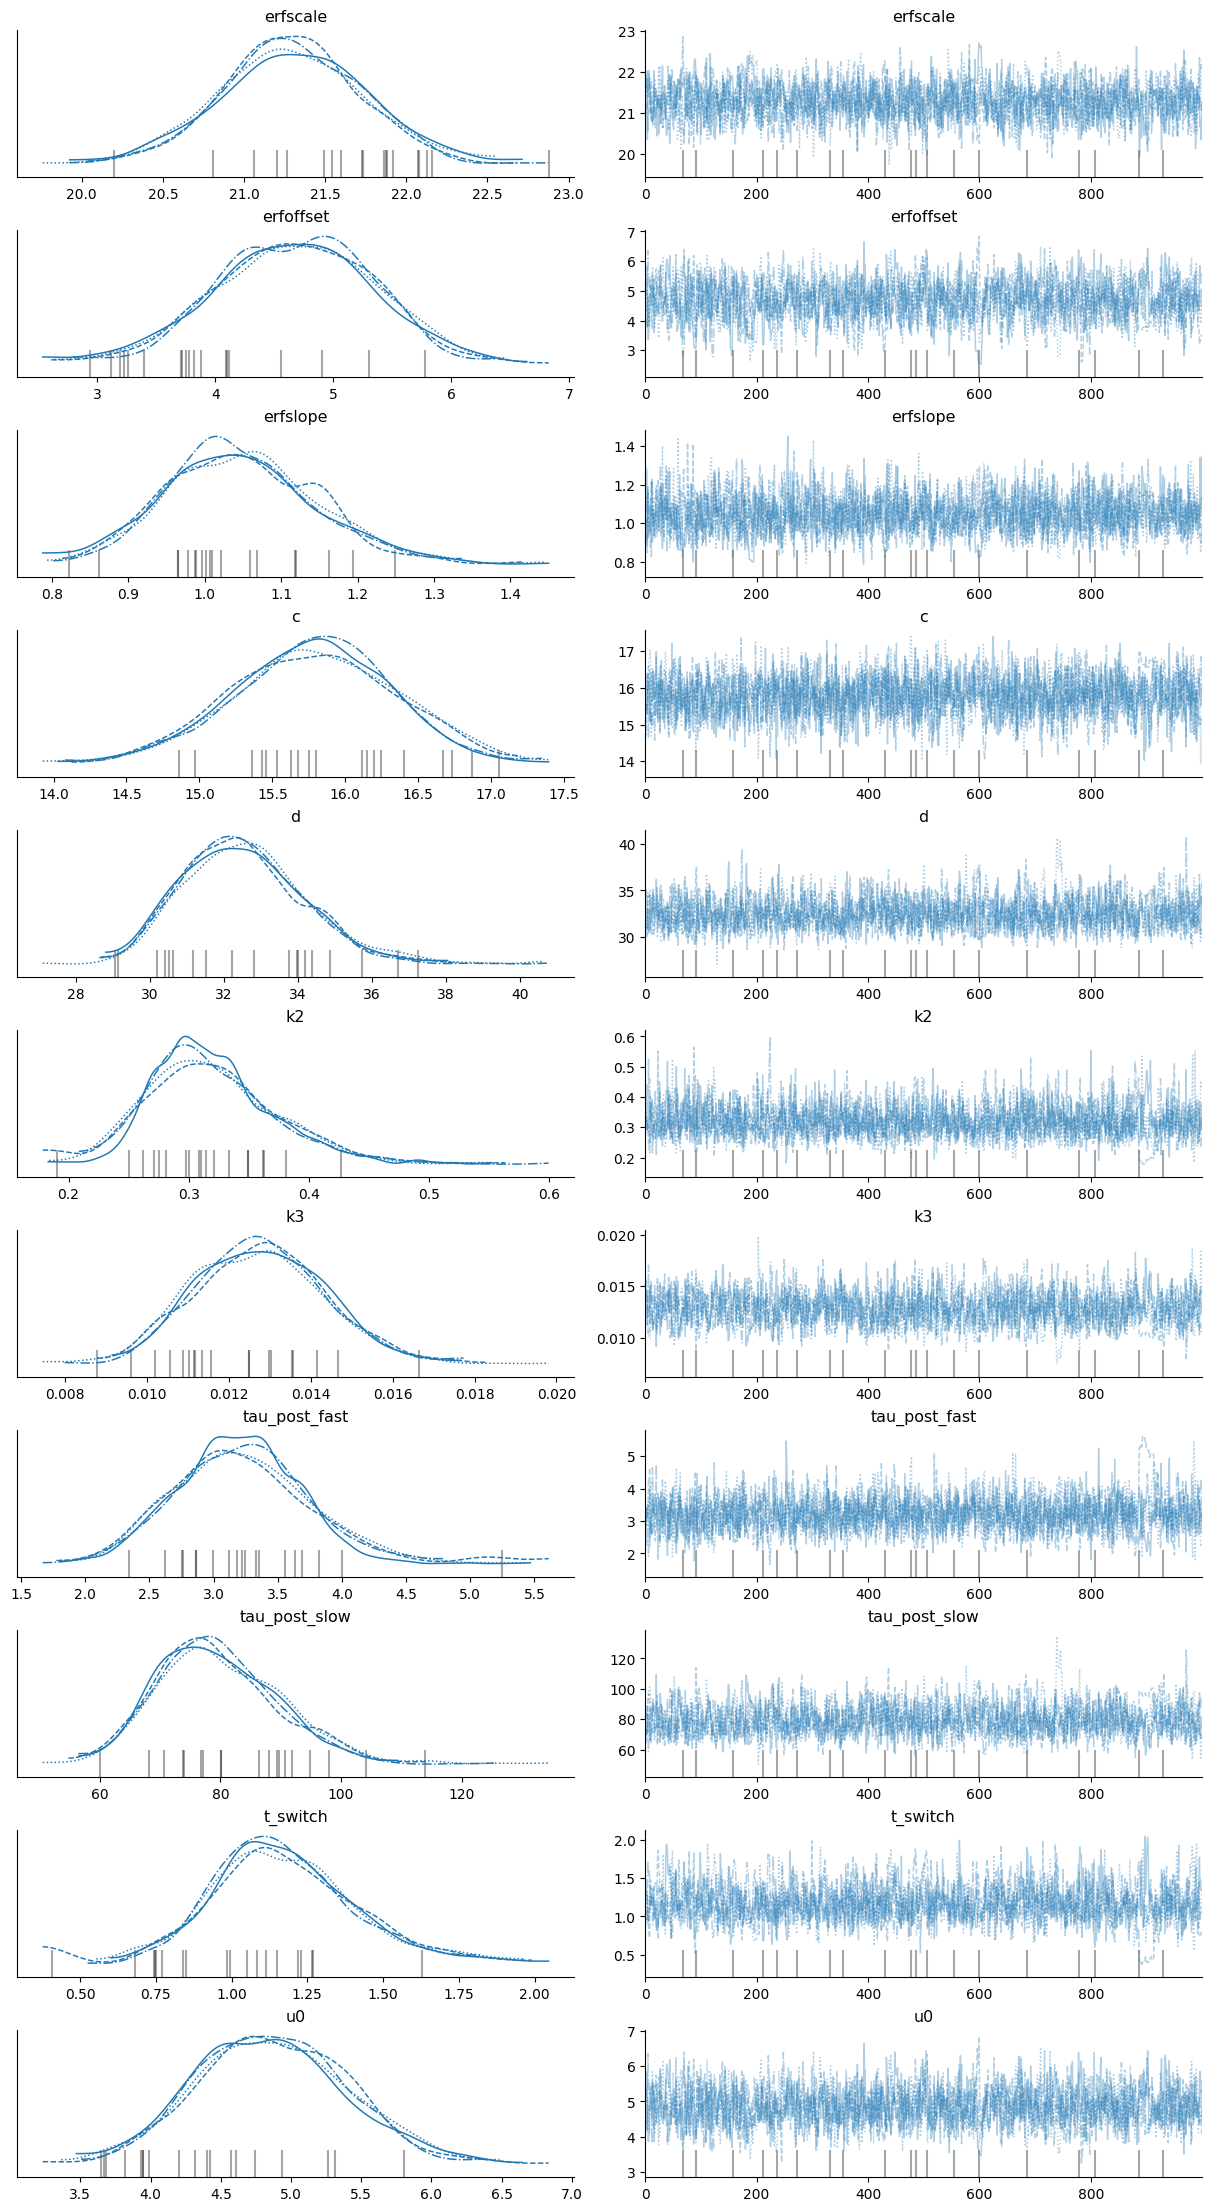

In [15]:
# plot the traces of the model
az.plot_trace(idata,backend_kwargs={'layout': 'constrained'},
              var_names=var_names
              )

## Compute predictions over a set of new input points

In [16]:
from rvm_analysis.bayesian_cell_models import compute_predictions_over_new_data


X_test = np.linspace(-10,100,2000)
idata_predictions = compute_predictions_over_new_data(off_model,idata,X_test)

Sampling: [count_pred_new]
[distfit] >INFO> Sampling: [count_pred_new]


In [17]:

# Extract posterior lambda and summarize
lambda_preds = idata_predictions.predictions['rate']
lambda_mean = lambda_preds.mean(("chain","draw"))
# lambda_mean

count_preds = idata_predictions.predictions['count_pred_new']
count_pred_mean = count_preds.mean(("chain","draw"))

In [18]:
preds_numpy = count_preds.to_numpy()
print(preds_numpy.shape)
preds_numpy = preds_numpy.T.reshape((2000,-1))
preds_numpy.shape

(4, 1000, 2000)


(2000, 4000)

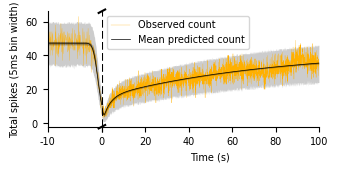

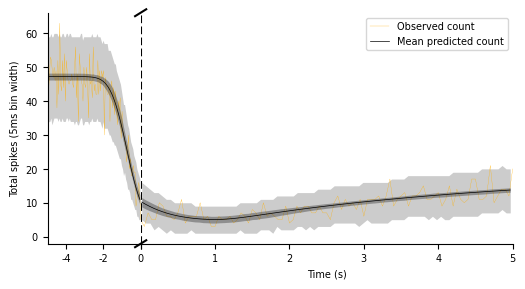

In [19]:
from rvm_analysis.plotting import plot_predictions_paper


plot_predictions_paper(counts,X_test,count_pred_mean,lambda_preds,lambda_mean,preds_numpy,x_bounds=(-10,100),figsize=(3.5,1.5),
                       filename="28_switching_model_OFF_cells_erf_aggregated",
                   basePath="./models/off_models/28_OFF_cells_erf",save=True)

plot_predictions_paper(counts,X_test,count_pred_mean,lambda_preds,lambda_mean,preds_numpy,x_bounds=(-5,5),figsize=(6,3),
                       filename="28_switching_model_OFF_cells_erf_aggregated",
                   basePath="./models/off_models/28_OFF_cells_erf",save=False)